In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [5]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

df.tail()

df.shape

df.columns

df.info()

df.describe()

df.sample(5)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1470,1471,15762332,Ulyanova,568,Germany,Female,31,1,61592.14,2,1,1,61796.64,0
826,827,15660535,Avent,680,France,Female,47,5,0.00,2,1,1,179843.33,0
7108,7109,15594812,Campbell,806,Spain,Female,37,2,137794.18,2,0,1,75232.02,0
3937,3938,15610165,Hsiung,761,France,Female,26,1,0.00,2,1,1,199409.19,0
2731,2732,15712584,Liao,670,France,Female,33,7,0.00,2,1,1,88187.81,0


In [7]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [8]:
df["Exited"].value_counts()

df["Exited"].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

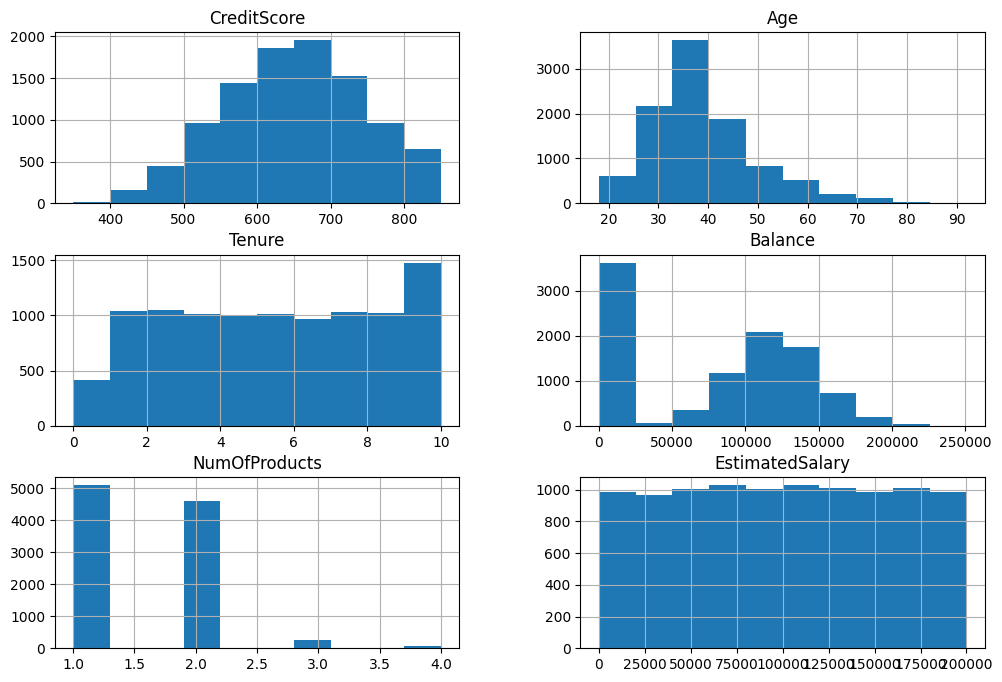

In [10]:
numerical_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]
df[numerical_cols].hist(figsize=(12,8))
plt.show()

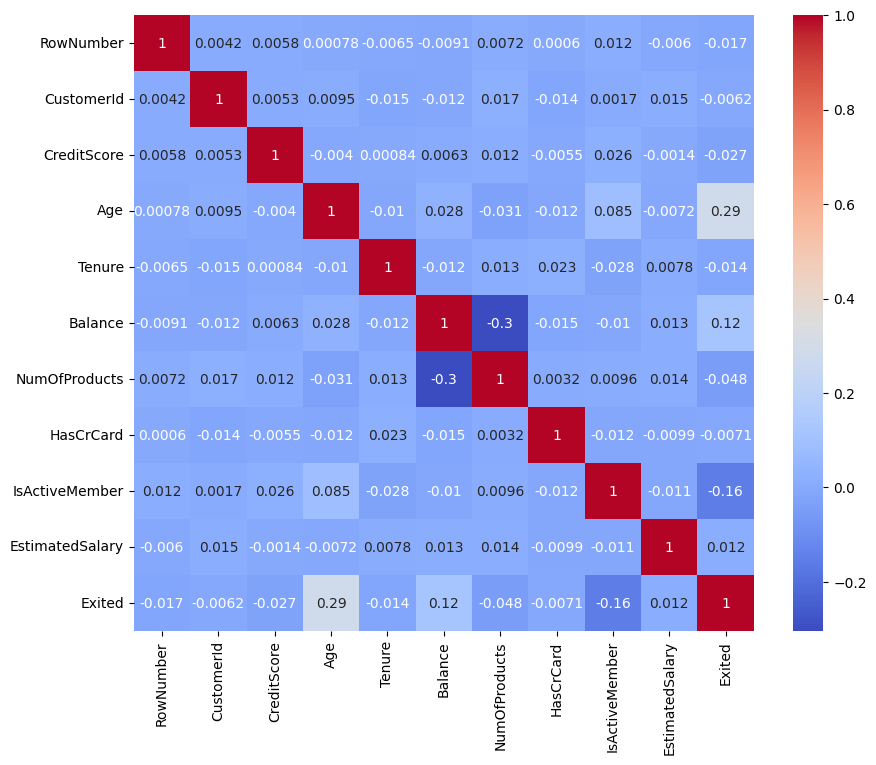

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

<Axes: xlabel='Geography', ylabel='count'>

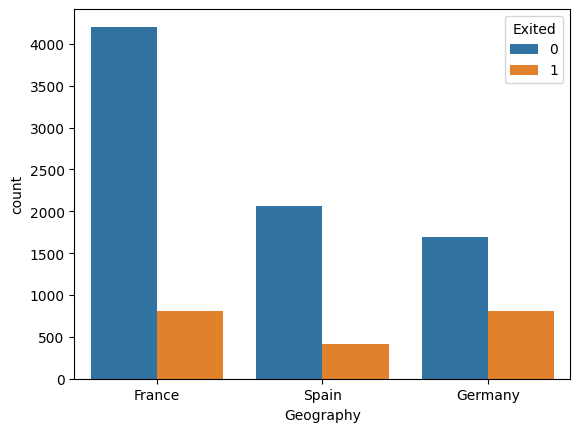

In [12]:
# Geography vs Churn
sns.countplot(
    x="Geography",
    hue="Exited",
    data=df
)

<Axes: xlabel='Gender', ylabel='count'>

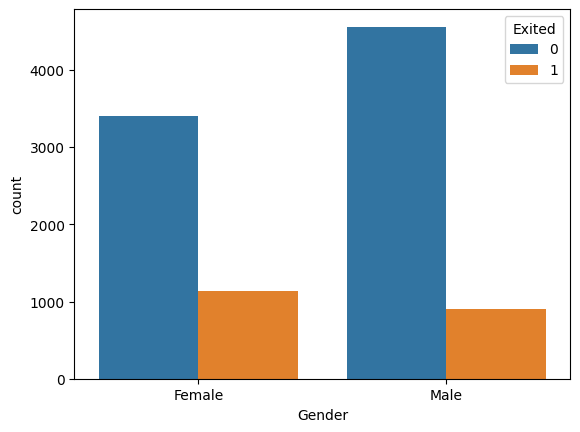

In [13]:
# Gender vs Churn 
sns.countplot(
    x="Gender",
    hue="Exited",
    data=df
)

<Axes: xlabel='Exited', ylabel='Age'>

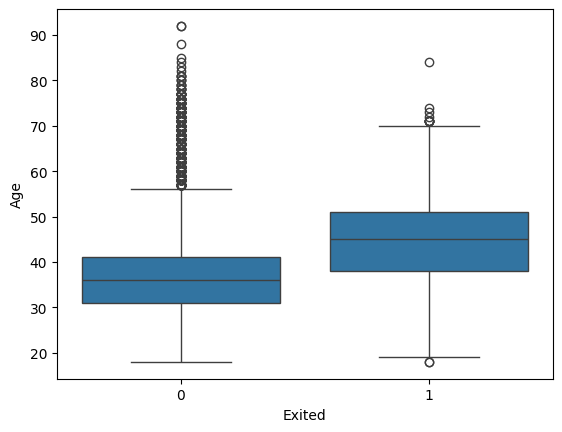

In [14]:
# Age vs Churn
sns.boxplot(
    x="Exited",
    y="Age",
    data=df
)

In [15]:
# These columns do not help predict churn because they are identifiers or names:
df.drop(
    ["RowNumber","CustomerId","Surname"],
    axis=1,
    inplace=True
)

In [16]:
# NOW Encoding Categorical Variables
# FIRST IS GENDER

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

In [17]:
# SECOND IS Geography

df = pd.get_dummies(
    df,
    columns=["Geography"],
    drop_first=True
)

In [18]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

In [19]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
# Feature Scaling Only for Logistic Regression.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# MODEL 1 Logistic Regression
lr = LogisticRegression()
lr.fit(
    X_train_scaled,
    y_train
)

LogisticRegression()

In [23]:
# MODEL 2 RANDOM FOREST

rf = RandomForestClassifier(
    random_state=42
)
rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [24]:
# MODEL 3 GRADIENT BOOSTING

gb = GradientBoostingClassifier(
    random_state=42
)
gb.fit(
    X_train,
    y_train
)

GradientBoostingClassifier(random_state=42)

In [25]:
lr_pred = lr.predict(X_test_scaled)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

In [26]:
# Evaluation Function
def evaluate_model(model, X_test, y_test, model_name):
    # Predictions
    y_pred = model.predict(X_test)

    # Probability predictions
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("=" * 60)
    print(f"{model_name}")
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return accuracy, roc_auc

In [27]:
# EVALUATE FOR Logistic Regression
lr_acc, lr_auc = evaluate_model(
    lr,
    X_test_scaled,
    y_test,
    "Logistic Regression"
)

Logistic Regression
Accuracy : 0.8080
ROC-AUC  : 0.7748

Confusion Matrix
[[1540   53]
 [ 331   76]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [28]:
# EVALUATE FOR RANDOM FOREST
rf_acc, rf_auc = evaluate_model(
    rf,
    X_test,
    y_test,
    "Random Forest"
)

Random Forest
Accuracy : 0.8610
ROC-AUC  : 0.8545

Confusion Matrix
[[1538   55]
 [ 223  184]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.77      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



In [29]:
# EVALUATE FOR GRADIENT BOOSTING

gb_acc, gb_auc = evaluate_model(
    gb,
    X_test,
    y_test,
    "Gradient Boosting"
)

Gradient Boosting
Accuracy : 0.8700
ROC-AUC  : 0.8708

Confusion Matrix
[[1541   52]
 [ 208  199]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [30]:
# Comparison Table
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        lr_acc,
        rf_acc,
        gb_acc
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc,
        gb_auc
    ]
})

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.808,0.774778
1,Random Forest,0.861,0.854485
2,Gradient Boosting,0.870,0.870831


In [33]:
# Probability Scores

# Logistic Regression
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

# Random Forest
rf_prob = rf.predict_proba(X_test)[:, 1]

# Gradient Boosting
gb_prob = gb.predict_proba(X_test)[:, 1]

In [34]:
# Compute ROC Curve

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
auc_lr = roc_auc_score(y_test, lr_prob)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
auc_rf = roc_auc_score(y_test, rf_prob)

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)
auc_gb = roc_auc_score(y_test, gb_prob)

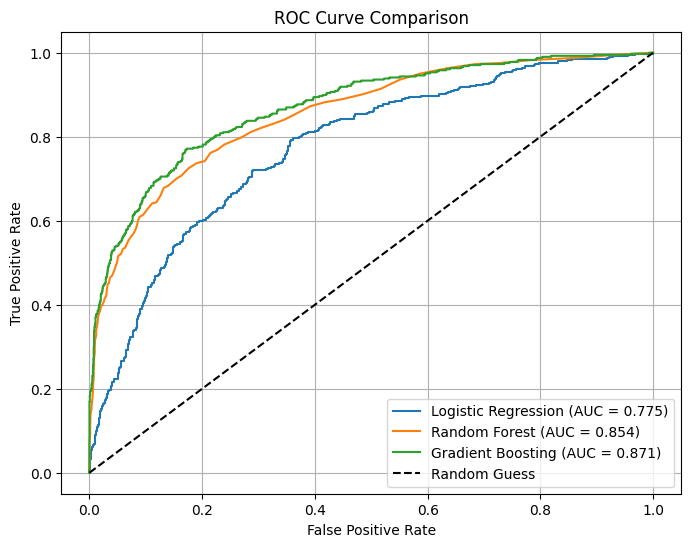

In [35]:
# Plot All ROC Curves
plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr,
         label=f"Logistic Regression (AUC = {auc_lr:.3f})")

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC = {auc_rf:.3f})")

plt.plot(fpr_gb, tpr_gb,
         label=f"Gradient Boosting (AUC = {auc_gb:.3f})")

# Random Guess Line
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend(loc="lower right")
plt.grid(True)

plt.show()